In [2]:
import torch

In [31]:
#Conv 1d for time series, 2d for image, 3d for volume/video data
net = torch.nn.Conv2d(1, 16, 3, 4, (3 - 1) // 2) # just an example 
x = torch.randn(11, 1, 28, 28) 
# batch size, channel, width, height
print(x.shape)

torch.Size([11, 1, 28, 28])


In [32]:
y = net(x)
print(y.shape)

torch.Size([11, 16, 7, 7])


In [33]:
class ConvNet(torch.nn.Module):
    def __init__(self, layers=[16, 32, 64], kernel_size=3, stride=1):
        super().__init__()
        cnn_layers = []
        c1 = 1 # in this example the input is only of channel 1
        for c2 in layers: # layers are the channel size
            cnn_layers.append(torch.nn.Conv2d(c1, c2, kernel_size, stride, (kernel_size - 1) // 2))
            cnn_layers.append(torch.nn.ReLU())
            c1 = c2
        cnn_layers.append(torch.nn.Conv2d(c1, 1, kernel_size=1))
        # cnn_layers.append(torch.nn.AdaptiveAvgPool2d(1)) <-- avg the output of the classifier
        self.network = torch.nn.Sequential(*cnn_layers)

    def forward(self, x):
        return self.network(x)


net = ConvNet(stride=1)

net(x).shape

torch.Size([11, 1, 28, 28])

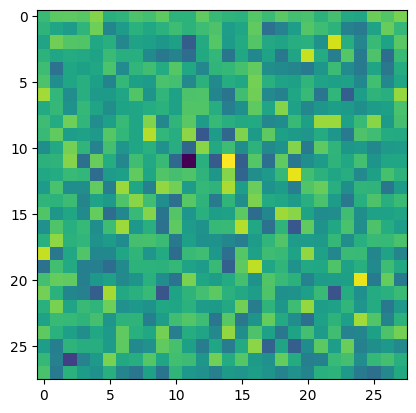

In [5]:
# capture the receptive field
from matplotlib import pyplot as plt
x = torch.randn(1, 1, 28, 28)
net = ConvNet()
y = net(x)
plt.imshow(y[0,0].detach().numpy()) # its a single value of each plot on the graph
# matplotlib puts some pesudocolor logic. We could have also said plt.imshow(y[0,0].detach().numpy(), cmap='gray')


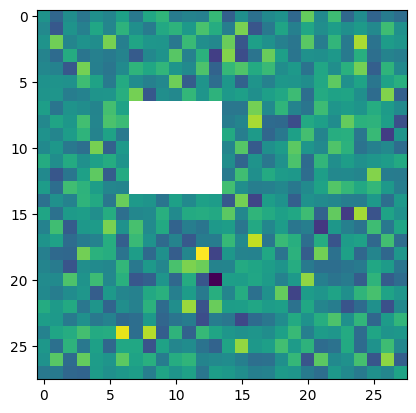

In [24]:
x[0,0,10,10] = float('NaN')
y = net(x)
plt.imshow(y[0,0].detach().numpy())


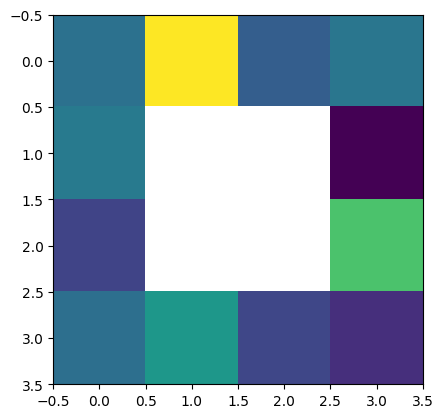

In [25]:
# with striding the same effect will be on a larger scale
net2= ConvNet(stride=2)
y2 = net2(x)
plt.imshow(y2[0,0].detach().numpy())

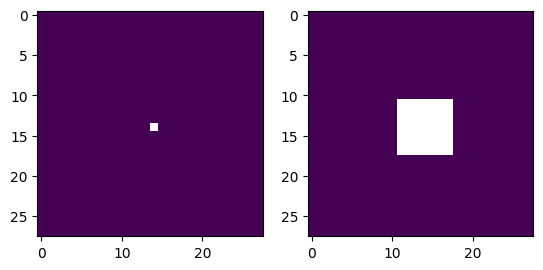

In [6]:
# capture the receptive for a given output

x = torch.randn(1, 1, 28, 28, requires_grad=True)
net = ConvNet(stride=1)
y = net(x)

z = y.new_zeros(y.shape)
# probe 
z[0, 0, z.shape[2] // 2, z.shape[3] // 2] = float("NaN") # set one element to NaN
f, ax = plt.subplots(1, 2)
ax[0].imshow(z[0, 0].detach().numpy())

(y * z).sum().backward()

# the below plot shows the effect to the original input of making one position NaN in the output
ax[1].imshow(x.grad[0, 0].detach().numpy())

In [8]:
# Block driven Conv Net
class ConvNet(torch.nn.Module):
    class Block(torch.nn.Module):
        def __init__(self, in_channels, out_channels, stride):
            super().__init__()
            kernel_size = 3
            padding = (kernel_size - 1) // 2

            self.c1 = torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
            self.c2 = torch.nn.Conv2d(out_channels, out_channels, kernel_size, 1, padding)
            self.c3 = torch.nn.Conv2d(out_channels, out_channels, kernel_size, 1, padding)
            self.relu = torch.nn.ReLU()

        def forward(self, x):
            x = self.relu(self.c1(x))
            x = self.relu(self.c2(x))
            x = self.relu(self.c3(x))
            return x

    def __init__(self, channels_l0=64, n_blocks=4):
        super().__init__()
        cnn_layers = [
            # very first layer blows up the channel and then shrinks the height and weight
            # very first layer also uses a bigger kernel
            torch.nn.Conv2d(3, channels_l0, kernel_size=11, stride=2, padding=5),
            torch.nn.ReLU(),
        ]
        c1 = channels_l0
        for _ in range(n_blocks):
            c2 = c1 * 2
            # each block will have a sequence of conv nets
            cnn_layers.append(self.Block(c1, c2, stride=2))
            c1 = c2
        # last one is one channel which project all the channel info across the image into 1 definitive channel
        # at this point, each pixel can indicate what the pixel is most likely to be, a dog, cat or something else
        # then if classification is needed on entire image, AdaptiveAvgPool2d can be used 
        cnn_layers.append(torch.nn.Conv2d(c1, 1, kernel_size=1))
        # cnn_layers.append(torch.nn.AdaptiveAvgPool2d(1))
        self.network = torch.nn.Sequential(*cnn_layers)

    def forward(self, x):
        return self.network(x)


net = ConvNet(n_blocks=3)
x = torch.randn(1, 3, 64, 64)
print(net(x).shape)
print(net(x))


torch.Size([1, 1, 4, 4])
tensor([[[[-0.0024, -0.0037, -0.0036, -0.0035],
          [-0.0014, -0.0026, -0.0028, -0.0043],
          [-0.0012, -0.0019, -0.0024, -0.0041],
          [-0.0004, -0.0006, -0.0013, -0.0033]]]],
       grad_fn=<ConvolutionBackward0>)


In [10]:
net = torch.nn.Conv2d(1, 3, 3, stride=2, padding=1, dilation=1)
print(f"{list(net.parameters())=}")

# output has one set of parameters for the kernel/weights that is multiplied by input X
# output has another set of parameters for bias size of which depends on channel size

list(net.parameters())=[Parameter containing:
tensor([[[[-0.0883, -0.0481, -0.2695],
          [ 0.3227,  0.2674,  0.2504],
          [-0.0016,  0.1566,  0.0017]]],


        [[[-0.0322, -0.1415,  0.2046],
          [ 0.2577,  0.0734,  0.3289],
          [ 0.0535,  0.0144,  0.0111]]],


        [[[ 0.1733, -0.3161,  0.0264],
          [-0.2424,  0.1891,  0.3046],
          [ 0.2750,  0.2013,  0.1334]]]], requires_grad=True), Parameter containing:
tensor([0.1006, 0.0325, 0.2473], requires_grad=True)]


In [13]:
# check effect of dilation 
net1 = torch.nn.Sequential(
    torch.nn.Conv2d(1, 1, 3, stride=2, padding=1, dilation=1),
    torch.nn.ReLU(),
    torch.nn.Conv2d(1, 1, 3, stride=1, padding=1, dilation=1),
)
net2 = torch.nn.Sequential(
    torch.nn.Conv2d(1, 1, 3, stride=1, padding=1, dilation=1),
    torch.nn.ReLU(),
    torch.nn.Conv2d(1, 1, 3, stride=1, padding=2, dilation=2),
    # dilation 2 effectively makes kernel size change to 5, thus padding has to be (5-1)/2 = 2
)

# Copy one network's parameters to another one
for p1, p2 in zip(net1.parameters(), net2.parameters()):
    p2.data = p1.data.clone()
    p2.requires_grad = True

x = torch.randn(1, 1, 5, 5)
print(f"{x.shape=}, {net1(x).shape=}")
print(f"{x.shape=}, {net2(x).shape=}")
y1 = net1(x)
y2 = net2(x)
print(f"{y1=}")
print(f"{y2=}")

x.shape=torch.Size([1, 1, 5, 5]), net1(x).shape=torch.Size([1, 1, 3, 3])
x.shape=torch.Size([1, 1, 5, 5]), net2(x).shape=torch.Size([1, 1, 5, 5])
y1=tensor([[[[-0.2709, -0.4031, -0.3066],
          [-0.4055, -0.3493, -0.4272],
          [-0.0828, -0.1976, -0.2761]]]], grad_fn=<ConvolutionBackward0>)
y2=tensor([[[[-0.2709, -0.3266, -0.4031, -0.2690, -0.3066],
          [-0.3695, -0.1624, -0.2797, -0.5329, -0.3927],
          [-0.4055, -0.1753, -0.3493, -0.3123, -0.4272],
          [-0.1447, -0.5709, -0.1955, -0.2921, -0.2682],
          [-0.0828, -0.3332, -0.1976, -0.2689, -0.2761]]]],
       grad_fn=<ConvolutionBackward0>)


In [3]:
net1 = torch.nn.Sequential(
    torch.nn.Conv2d(1, 1, 3, stride=2, padding=1, dilation=1),
    torch.nn.ReLU(),
    torch.nn.Conv2d(1, 1, 3, stride=1, padding=1, dilation=1),
    torch.nn.ReLU(),
    # the below is upconvoluation in which 0 is inserted in input
    # stride decides how much to upsample so stride=2 will insert one 0 between each input element
    torch.nn.ConvTranspose2d(1, 1, 3, stride=2, padding=1, output_padding=1),
    # padding controls the amount of implicit zero padding on both sides of input
    # zero padding =  dilation * (kernel_size - 1) - padding number of points
    # for output_padding its not clear how but it decides if a N size matrix should yield
    # 2N or 2N-1 matrix. If output_padding is 1, it yields the higher one. 
)

# x = torch.randn(1, 1, 6, 6) and x = torch.randn(1, 1, 5, 5) yield the same output size after first conv
# that is because in 6x6, the last kernel computation doesnt happen because of lack of input
x = torch.randn(10, 1, 6, 6)
# print(f"{net1(x).shape=} {net1(x)=}")

# the below produces same output shape as input by cutting out the last row/column if needed
print(net1(x)[:, :, : x.shape[2], : x.shape[3]].shape)

torch.Size([10, 1, 6, 6])
